In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 1 Load Data

In [2]:
step2_dir = "./results_step2"

user_embeddings = np.load(f"{step2_dir}/user_embeddings.npy")
item_embeddings = np.load(f"{step2_dir}/item_embeddings.npy")

user_index_table = pd.read_csv(f"{step2_dir}/user_index_table.csv")
item_index_table = pd.read_csv(f"{step2_dir}/item_index_table.csv")

load_summary = pd.DataFrame([
    {
        "object": "user_embeddings",
        "shape": user_embeddings.shape,
    },
    {
        "object": "item_embeddings",
        "shape": item_embeddings.shape,
    },
    {
        "object": "user_index_table",
        "shape": user_index_table.shape,
    },
    {
        "object": "item_index_table",
        "shape": item_index_table.shape,
    },
])

display(load_summary)

display(user_index_table.head())
display(item_index_table.head())

,object,shape
0,user_embeddings,"(4722, 64)"
1,item_embeddings,"(3250, 64)"
2,user_index_table,"(4722, 2)"
3,item_index_table,"(3250, 2)"


,user_idx,user_id
0,0,1
1,1,2
2,2,3
3,3,5
4,4,6


,item_idx,movie_id
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


### Basic Embedding Checks

Before clustering, we verify that:

- the number of user embeddings matches the user index table;
- the number of item embeddings matches the item index table;
- all embedding values are finite;
- embeddings have a reasonable numeric range.

This is a necessary sanity check before using distance-based clustering.

In [3]:
embedding_check = pd.DataFrame([
    {
        "object": "user_embeddings",
        "rows": user_embeddings.shape[0],
        "dimensions": user_embeddings.shape[1],
        "min_value": float(user_embeddings.min()),
        "max_value": float(user_embeddings.max()),
        "mean_value": float(user_embeddings.mean()),
        "std_value": float(user_embeddings.std()),
        "all_finite": bool(np.isfinite(user_embeddings).all()),
    },
    {
        "object": "item_embeddings",
        "rows": item_embeddings.shape[0],
        "dimensions": item_embeddings.shape[1],
        "min_value": float(item_embeddings.min()),
        "max_value": float(item_embeddings.max()),
        "mean_value": float(item_embeddings.mean()),
        "std_value": float(item_embeddings.std()),
        "all_finite": bool(np.isfinite(item_embeddings).all()),
    },
])

display(embedding_check)

assert len(user_index_table) == user_embeddings.shape[0]
assert len(item_index_table) == item_embeddings.shape[0]
assert np.isfinite(user_embeddings).all()
assert np.isfinite(item_embeddings).all()

,object,rows,dimensions,min_value,max_value,mean_value,std_value,all_finite
0,user_embeddings,4722,64,-0.857286,0.818325,0.003990,0.181612,True
1,item_embeddings,3250,64,-1.060074,1.140021,-0.000921,0.196268,True


# 2 User Embedding Scale and Preprocessing Decision

DBSCAN is distance-based, so preprocessing matters.

We focus on user embeddings because the final project needs group recommendation. User clusters can later be used to create:

- homogeneous groups from the same taste community;
- diverse groups across different taste communities;
- groups including noise/outlier users.

Before choosing DBSCAN parameters, we inspect the scale of user embeddings and compare simple preprocessing options.

In [4]:
# Raw user embeddings
user_embeddings_raw = user_embeddings.copy()

# Option 1: standardize each embedding dimension
scaler = StandardScaler()
user_embeddings_standardized = scaler.fit_transform(user_embeddings_raw)

# Option 2: L2-normalize raw embeddings
user_embeddings_l2 = normalize(
    user_embeddings_raw,
    norm="l2",
)

# Option 3: standardize first, then L2-normalize
user_embeddings_standardized_l2 = normalize(
    user_embeddings_standardized,
    norm="l2",
)


def summarize_embedding_matrix(name, matrix):
    row_norms = np.linalg.norm(matrix, axis=1)
    dim_std = matrix.std(axis=0)

    return {
        "version": name,
        "rows": matrix.shape[0],
        "dimensions": matrix.shape[1],
        "global_mean": round(float(matrix.mean()), 6),
        "global_std": round(float(matrix.std()), 6),
        "min_value": round(float(matrix.min()), 6),
        "max_value": round(float(matrix.max()), 6),
        "avg_l2_norm": round(float(row_norms.mean()), 6),
        "min_l2_norm": round(float(row_norms.min()), 6),
        "max_l2_norm": round(float(row_norms.max()), 6),
        "min_dimension_std": round(float(dim_std.min()), 6),
        "max_dimension_std": round(float(dim_std.max()), 6),
    }


preprocessing_summary = pd.DataFrame([
    summarize_embedding_matrix("raw", user_embeddings_raw),
    summarize_embedding_matrix("standardized", user_embeddings_standardized),
    summarize_embedding_matrix("l2_normalized_raw", user_embeddings_l2),
    summarize_embedding_matrix("standardized_then_l2", user_embeddings_standardized_l2),
])

display(preprocessing_summary)

,version,rows,dimensions,global_mean,global_std,min_value,max_value,avg_l2_norm,min_l2_norm,max_l2_norm,min_dimension_std,max_dimension_std
0,raw,4722,64,0.003990,0.181612,-0.857286,0.818325,1.382586,0.211152,2.430290,0.103449,0.229068
1,standardized,4722,64,-0.000000,1.000000,-5.717645,5.464437,7.547279,1.174033,17.159935,0.999999,1.000001
2,l2_normalized_raw,4722,64,0.002856,0.124967,-0.600114,0.501972,1.000000,1.000000,1.000000,0.068146,0.158246
3,standardized_then_l2,4722,64,-0.000394,0.124999,-0.484343,0.470737,1.000000,1.000000,1.000000,0.122139,0.128079


# 3 k-distance Analysis for DBSCAN

DBSCAN has two important parameters:

- `eps`: maximum distance between users for them to be considered neighbors;
- `min_samples`: minimum number of nearby users required to form a dense region.

Because `min_samples` is not known in advance, we test several candidate values.

Small values such as 5–30 allow DBSCAN to find smaller local taste communities.  
Larger values such as 100–500 are stricter and are used as sensitivity checks.

This analysis helps us define a reasonable search range for `eps` before running the final DBSCAN grid search.

In [5]:
user_embeddings_dbscan = user_embeddings_standardized_l2

min_samples_candidates = [5, 10, 20, 30, 50, 100, 200, 500]

min_samples_scale = pd.DataFrame({
    "min_samples": min_samples_candidates,
    "share_of_users": [
        round(x / user_embeddings_dbscan.shape[0], 4)
        for x in min_samples_candidates
    ],
})

display(min_samples_scale)

,min_samples,share_of_users
0,5,0.0011
1,10,0.0021
2,20,0.0042
3,30,0.0064
4,50,0.0106
5,100,0.0212
6,200,0.0424
7,500,0.1059


In [6]:
k_distance_rows = []

for min_samples in min_samples_candidates:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
    )

    neighbors.fit(user_embeddings_dbscan)

    distances, indices = neighbors.kneighbors(user_embeddings_dbscan)

    k_distances = np.sort(distances[:, -1])

    for q in [0.50, 0.75, 0.90, 0.95, 0.99]:
        k_distance_rows.append({
            "min_samples": min_samples,
            "percentile": q,
            "k_distance": np.quantile(k_distances, q),
        })

k_distance_summary = pd.DataFrame(k_distance_rows)

display(k_distance_summary)

,min_samples,percentile,k_distance
0,5,0.50,0.897003
1,5,0.75,0.976936
2,5,0.90,1.029414
3,5,0.95,1.053003
4,5,0.99,1.091927
5,10,0.50,0.929383
6,10,0.75,1.007526
7,10,0.90,1.058341
8,10,0.95,1.082514
9,10,0.99,1.120663


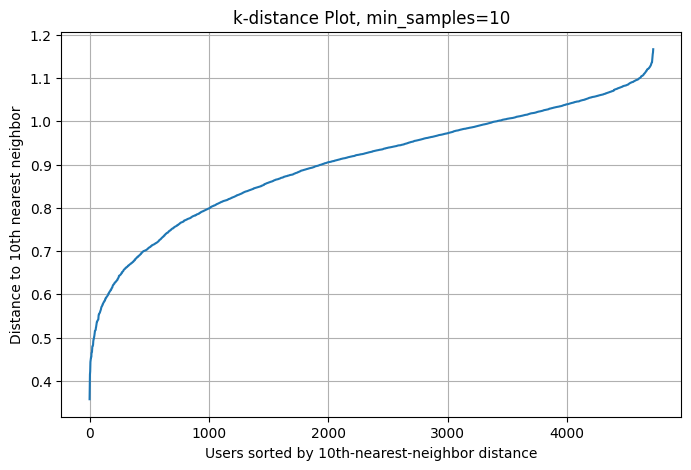

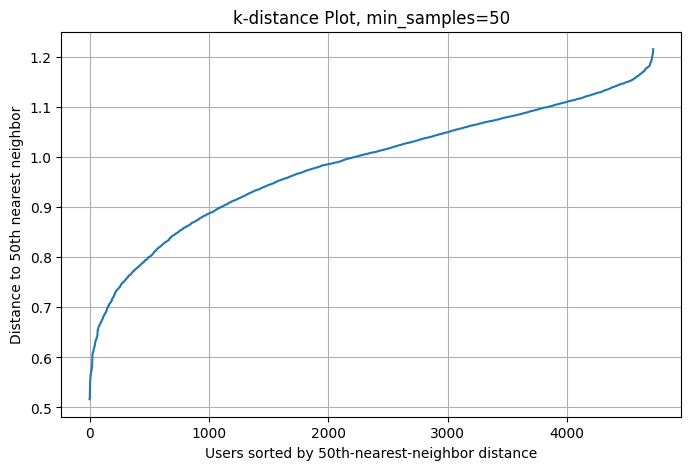

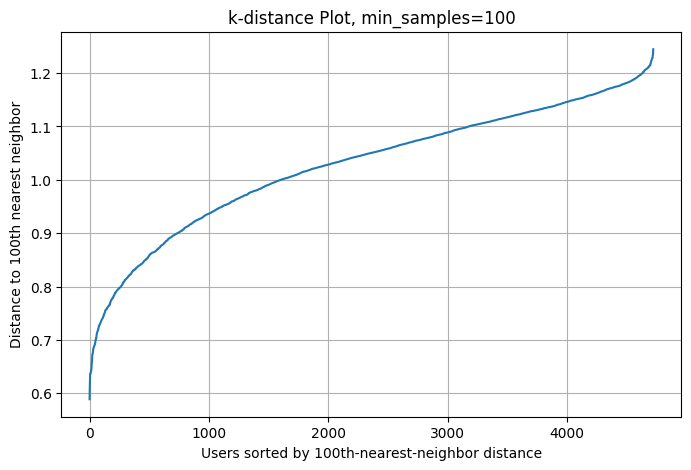

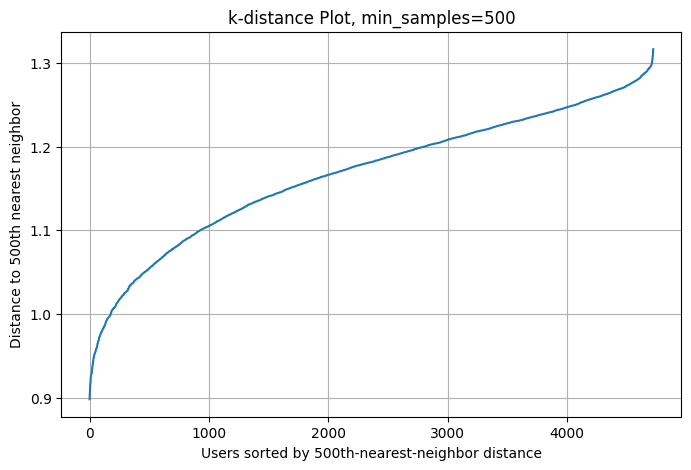

In [7]:
plot_min_samples = [10, 50, 100, 500]

for min_samples in plot_min_samples:
    neighbors = NearestNeighbors(
        n_neighbors=min_samples,
        metric="euclidean",
    )

    neighbors.fit(user_embeddings_dbscan)

    distances, indices = neighbors.kneighbors(user_embeddings_dbscan)

    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(8, 5))
    plt.plot(k_distances)
    plt.xlabel(f"Users sorted by {min_samples}th-nearest-neighbor distance")
    plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
    plt.title(f"k-distance Plot, min_samples={min_samples}")
    plt.grid(True)
    plt.show()

# 4 DBSCAN Grid Search on Full User Embeddings

We first test DBSCAN directly on the full 64-dimensional BPR user embeddings.

DBSCAN has two main parameters:

- `eps`: maximum distance between two users for them to be considered neighbors;
- `min_samples`: minimum number of nearby users required to form a dense region.

A useful clustering result should avoid:

- only one cluster;
- one giant cluster containing almost all users;
- excessive noise;
- tiny artificial clusters.

This experiment helps us decide whether full-space DBSCAN is sufficient, or whether dimensionality reduction is needed before clustering.

In [ ]:
user_embeddings_dbscan = user_embeddings_standardized_l2

eps_values = [
    0.90, 0.95, 1.00, 1.03, 1.05,
    1.08, 1.10, 1.12, 1.15, 1.18,
    1.20, 1.22, 1.25, 1.28, 1.30,
]

min_samples_grid = [5, 10, 20, 30, 50, 100]


def summarize_dbscan_labels(labels):
    n_users = len(labels)
    cluster_labels = [label for label in set(labels) if label != -1]

    n_clusters = len(cluster_labels)
    n_noise = int((labels == -1).sum())
    noise_share = round(n_noise / n_users, 4)

    if n_clusters == 0:
        return {
            "n_clusters": 0,
            "n_noise": n_noise,
            "noise_share": noise_share,
            "largest_cluster_size": 0,
            "largest_cluster_share": 0.0,
            "smallest_cluster_size": 0,
            "median_cluster_size": 0.0,
        }

    cluster_sizes = [
        int((labels == cluster_id).sum())
        for cluster_id in cluster_labels
    ]

    return {
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_share": noise_share,
        "largest_cluster_size": max(cluster_sizes),
        "largest_cluster_share": round(max(cluster_sizes) / n_users, 4),
        "smallest_cluster_size": min(cluster_sizes),
        "median_cluster_size": float(np.median(cluster_sizes)),
    }


dbscan_grid_rows = []

for min_samples in min_samples_grid:
    for eps in eps_values:
        dbscan_model = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = dbscan_model.fit_predict(user_embeddings_dbscan)
        summary = summarize_dbscan_labels(labels)

        dbscan_grid_rows.append({
            "eps": eps,
            "min_samples": min_samples,
            **summary,
        })

dbscan_grid = pd.DataFrame(dbscan_grid_rows)

print("Number of tested configurations:", len(dbscan_grid))

DBSCAN grid search finished.
Number of tested configurations: 90


### 4.1 Compact Grid Summary

Instead of displaying the full DBSCAN grid, we summarize the main failure modes.

A configuration is considered potentially useful only if it has:

- at least 2 clusters;
- noise share not above 50%;
- largest cluster not above 90% of users;
- no tiny cluster with fewer than 10 users.

In [9]:
dbscan_grid_analysis = dbscan_grid.copy()

dbscan_grid_analysis["one_cluster_only"] = (
    dbscan_grid_analysis["n_clusters"] == 1
)

dbscan_grid_analysis["giant_cluster"] = (
    dbscan_grid_analysis["largest_cluster_share"] >= 0.90
)

dbscan_grid_analysis["high_noise"] = (
    dbscan_grid_analysis["noise_share"] >= 0.50
)

dbscan_grid_analysis["tiny_cluster_problem"] = (
    (dbscan_grid_analysis["n_clusters"] > 1)
    & (dbscan_grid_analysis["smallest_cluster_size"] < 10)
)

dbscan_grid_analysis["potentially_useful"] = (
    (dbscan_grid_analysis["n_clusters"] >= 2)
    & (dbscan_grid_analysis["noise_share"] <= 0.50)
    & (dbscan_grid_analysis["largest_cluster_share"] <= 0.90)
    & (dbscan_grid_analysis["smallest_cluster_size"] >= 10)
)

dbscan_grid_summary = pd.DataFrame([
    {
        "condition": "all configurations",
        "count": len(dbscan_grid_analysis),
    },
    {
        "condition": "more than one cluster",
        "count": int((dbscan_grid_analysis["n_clusters"] > 1).sum()),
    },
    {
        "condition": "one cluster only",
        "count": int(dbscan_grid_analysis["one_cluster_only"].sum()),
    },
    {
        "condition": "giant cluster share >= 90%",
        "count": int(dbscan_grid_analysis["giant_cluster"].sum()),
    },
    {
        "condition": "noise share >= 50%",
        "count": int(dbscan_grid_analysis["high_noise"].sum()),
    },
    {
        "condition": "multi-cluster but smallest cluster < 10 users",
        "count": int(dbscan_grid_analysis["tiny_cluster_problem"].sum()),
    },
    {
        "condition": "potentially useful configurations",
        "count": int(dbscan_grid_analysis["potentially_useful"].sum()),
    },
])

display(dbscan_grid_summary)

,condition,count
0,all configurations,90
1,more than one cluster,1
2,one cluster only,89
3,giant cluster share >= 90%,75
4,noise share >= 50%,1
5,multi-cluster but smallest cluster < 10 users,1
6,potentially useful configurations,0


### 4.2 Multi-Cluster Configurations

We inspect only the configurations where DBSCAN found more than one cluster.

This is the key check: if multi-cluster solutions are rare or contain tiny artificial clusters, full-space DBSCAN is not useful for discovering stable user communities.

In [10]:
multi_cluster_configs = (
    dbscan_grid_analysis[dbscan_grid_analysis["n_clusters"] > 1]
    .sort_values(
        ["n_clusters", "largest_cluster_share", "noise_share"],
        ascending=[False, True, True],
    )
)

display(multi_cluster_configs)

,eps,min_samples,n_clusters,n_noise,noise_share,largest_cluster_size,largest_cluster_share,smallest_cluster_size,median_cluster_size,one_cluster_only,giant_cluster,high_noise,tiny_cluster_problem,potentially_useful
2,1.0,5,2,325,0.0688,4395,0.9307,2,2198.5,False,True,False,True,False


### 4.3 Candidate Configurations

We now filter for configurations that satisfy the basic quality criteria.

If this table is empty, then full-space DBSCAN did not produce a useful clustering solution.

In [12]:
candidate_configs = (
    dbscan_grid_analysis[dbscan_grid_analysis["potentially_useful"]]
    .sort_values(
        ["n_clusters", "noise_share", "largest_cluster_share"],
        ascending=[False, True, True],
    )
)

if len(candidate_configs) == 0:
    candidate_decision = pd.DataFrame([
        {
            "decision": "No full-space DBSCAN configuration selected",
            "reason": (
                "No configuration produced at least two meaningful clusters "
                "without a giant dominant cluster, excessive noise, or tiny artificial clusters."
            ),
            "next_step": "Test DBSCAN after dimensionality reduction"
        }
    ])

    display(candidate_decision)
else:
    display(candidate_configs)

,decision,reason,next_step
0,No full-space DBSCAN configuration selected,No configuration produced at least two meaning...,Test DBSCAN after dimensionality reduction


# Full-Space DBSCAN Interpretation

The DBSCAN grid search on the full 64-dimensional BPR user embeddings did not produce a useful multi-cluster solution.

Out of 90 tested configurations, 89 produced only one cluster. The only configuration with more than one cluster produced one giant cluster containing 93.1% of users and a tiny secondary cluster with only 2 users. This is not meaningful as a stable user community.

No configuration satisfied our candidate criteria: at least two clusters, no excessive noise, no giant dominant cluster, and no tiny artificial cluster.

Therefore, we do not select a final DBSCAN model from the full embedding space.

This does not mean that clustering is impossible. It means that the full embedding space does not show clear density-separated user communities for DBSCAN. Therefore, the next step is to test whether dimensionality reduction can reveal a cleaner structure before applying DBSCAN again.